In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

print("Machine Learning environment loaded successfully!")

Machine Learning environment loaded successfully!


In [2]:
# ============================================
# STEP 3 — LOAD ML DATASET
# ============================================

df_ml = pd.read_csv(
    "../data/processed/customer_intelligence.csv"
)

print("ML dataset loaded successfully!")
print("Rows:", df_ml.shape[0])
print("Columns:", df_ml.shape[1])

display(df_ml.head())

ML dataset loaded successfully!
Rows: 4322
Columns: 9


,CustomerID,Recency,Frequency,TotalRevenue,R_Score,F_Score,M_Score,RFM_Score,CustomerSegment
0,14646.0,2,76,279489.02,5,5,5,555,Champions
1,18102.0,1,62,256438.49,5,5,5,555,Champions
2,17450.0,8,55,187322.17,5,5,5,555,Champions
3,14911.0,1,248,132458.73,5,5,5,555,Champions
4,12415.0,24,26,123725.45,4,5,5,455,Champions


In [3]:
# ============================================
# STEP 5 — PREPARE ML FEATURES
# ============================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select behavioral features
X_cluster = df_ml[
    ["Recency", "Frequency", "TotalRevenue"]
].copy()

print("Features selected:")
display(X_cluster.head())

print("\nShape:", X_cluster.shape)

Features selected:


,Recency,Frequency,TotalRevenue
0,2,76,279489.02
1,1,62,256438.49
2,8,55,187322.17
3,1,248,132458.73
4,24,26,123725.45



Shape: (4322, 3)


In [4]:
# ============================================
# STEP 6 — FEATURE SCALING
# ============================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

print("Feature scaling completed!")
print("Scaled shape:", X_scaled.shape)

Feature scaling completed!
Scaled shape: (4322, 3)


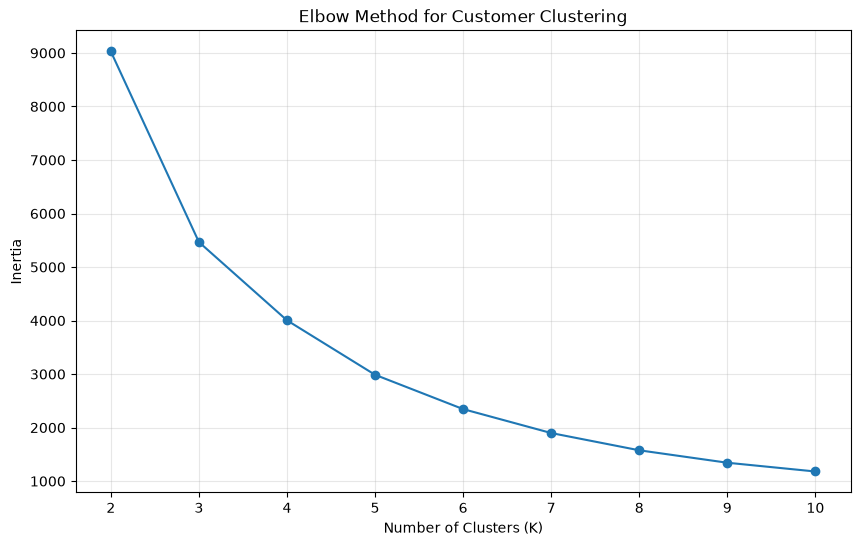

In [5]:
# ============================================
# STEP 7 — ELBOW METHOD
# ============================================

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), inertia, marker="o")

plt.title("Elbow Method for Customer Clustering")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(2, 11))
plt.grid(alpha=0.3)
plt.show()

In [6]:
# ============================================
# STEP 8 — K-MEANS CUSTOMER CLUSTERING
# ============================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df_ml["ML_Cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed!")
print("\nCustomers in each cluster:")
display(
    df_ml["ML_Cluster"]
    .value_counts()
    .sort_index()
)

K-Means clustering completed!

Customers in each cluster:


ML_Cluster
0    3144
1    1062
2     110
3       6
Name: count, dtype: int64

In [7]:
# ============================================
# STEP 9 — CLUSTER PROFILE
# ============================================

cluster_profile = (
    df_ml
    .groupby("ML_Cluster")
    .agg(
        Customers=("CustomerID", "count"),
        AvgRecency=("Recency", "mean"),
        AvgFrequency=("Frequency", "mean"),
        AvgRevenue=("TotalRevenue", "mean"),
        TotalRevenue=("TotalRevenue", "sum")
    )
    .round(2)
    .reset_index()
)

print("ML CUSTOMER CLUSTER PROFILE")
display(cluster_profile)

ML CUSTOMER CLUSTER PROFILE


,ML_Cluster,Customers,AvgRecency,AvgFrequency,AvgRevenue,TotalRevenue
0,0,3144,41.14,4.82,1481.49,4657802.17
1,1,1062,244.89,1.84,483.40,513374.97
2,2,110,9.18,40.66,18435.66,2027922.97
3,3,6,7.67,88.83,182108.08,1092648.45


In [8]:
# ============================================
# STEP 10 — ML CLUSTER vs RFM SEGMENT
# ============================================

cluster_rfm = pd.crosstab(
    df_ml["ML_Cluster"],
    df_ml["CustomerSegment"]
)

print("ML CLUSTER vs RFM SEGMENT")
display(cluster_rfm)

ML CLUSTER vs RFM SEGMENT


CustomerSegment,At Risk,Cannot Lose Them,Champions,Lost Customers,Loyal Customers,Needs Attention,New Customers,Potential Loyalists
ML_Cluster,,,,,,,,
0,198,111,833,177,470,537,323,495
1,96,137,0,616,0,213,0,0
2,1,0,107,0,0,0,0,2
3,0,0,6,0,0,0,0,0


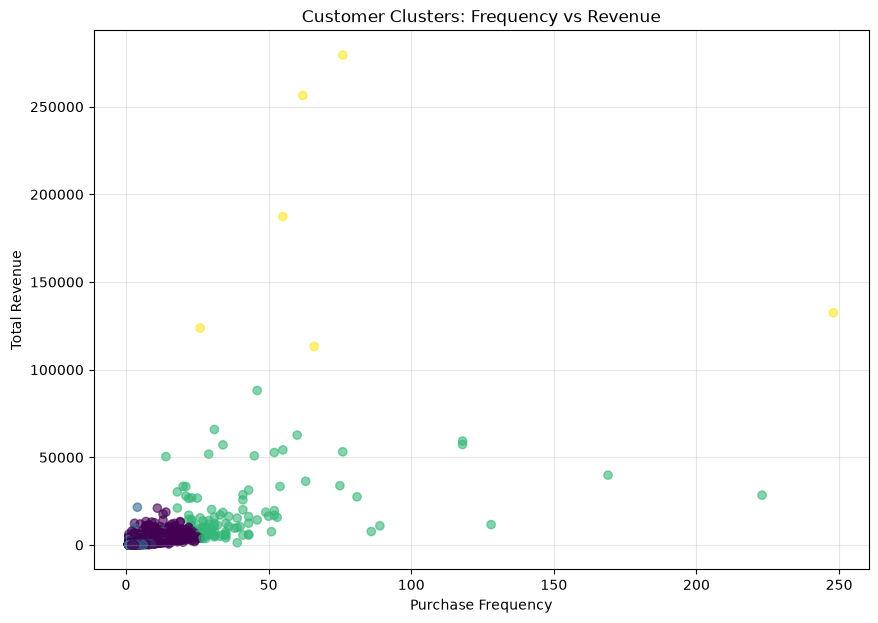

In [9]:
# ============================================
# STEP 11 — ML CLUSTER VISUALIZATION
# ============================================

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    df_ml["Frequency"],
    df_ml["TotalRevenue"],
    c=df_ml["ML_Cluster"],
    alpha=0.6
)

plt.title("Customer Clusters: Frequency vs Revenue")
plt.xlabel("Purchase Frequency")
plt.ylabel("Total Revenue")
plt.grid(alpha=0.3)

plt.show()

In [10]:
# ============================================
# STEP 12 — FINAL CLUSTER SUMMARY
# ============================================

cluster_summary = (
    df_ml
    .groupby("ML_Cluster")
    .agg(
        Customers=("CustomerID", "count"),
        AvgRecency=("Recency", "mean"),
        AvgFrequency=("Frequency", "mean"),
        AvgRevenue=("TotalRevenue", "mean"),
        TotalRevenue=("TotalRevenue", "sum")
    )
    .round(2)
    .sort_values("TotalRevenue", ascending=False)
    .reset_index()
)

print("FINAL ML CLUSTER SUMMARY")
display(cluster_summary)

FINAL ML CLUSTER SUMMARY


,ML_Cluster,Customers,AvgRecency,AvgFrequency,AvgRevenue,TotalRevenue
0,0,3144,41.14,4.82,1481.49,4657802.17
1,2,110,9.18,40.66,18435.66,2027922.97
2,3,6,7.67,88.83,182108.08,1092648.45
3,1,1062,244.89,1.84,483.40,513374.97


In [11]:
# ============================================
# STEP 13 — CLUSTER VALIDATION
# ============================================

from sklearn.metrics import silhouette_score

silhouette = silhouette_score(
    X_scaled,
    df_ml["ML_Cluster"]
)

print(f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.6125


In [12]:
# ============================================
# STEP 14 — COMPARE CLUSTER COUNTS
# ============================================

silhouette_scores = {}

for k in range(2, 8):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = model.fit_predict(X_scaled)
    
    score = silhouette_score(
        X_scaled,
        labels
    )
    
    silhouette_scores[k] = score

silhouette_df = pd.DataFrame(
    list(silhouette_scores.items()),
    columns=["K", "SilhouetteScore"]
)

display(silhouette_df)

,K,SilhouetteScore
0,2,0.894851
1,3,0.589348
2,4,0.612527
3,5,0.590059
4,6,0.592937
5,7,0.517679


In [13]:
# ============================================
# STEP 15 — BEST NUMBER OF CLUSTERS
# ============================================

best_k = silhouette_df.loc[
    silhouette_df["SilhouetteScore"].idxmax(),
    "K"
]

best_k = int(best_k)

print("Best number of clusters:", best_k)

Best number of clusters: 2


In [14]:
# ============================================
# STEP 16 — FINAL K-MEANS MODEL
# ============================================

final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df_ml["ML_Cluster"] = final_kmeans.fit_predict(X_scaled)

print("Final K-Means model trained!")
print("Number of clusters:", best_k)

display(
    df_ml["ML_Cluster"]
    .value_counts()
    .sort_index()
)

Final K-Means model trained!
Number of clusters: 2


ML_Cluster
0      26
1    4296
Name: count, dtype: int64

In [15]:
# ============================================
# STEP 17 — FINAL ML CLUSTER PROFILES
# ============================================

final_cluster_profile = (
    df_ml
    .groupby("ML_Cluster")
    .agg(
        Customers=("CustomerID", "count"),
        AvgRecency=("Recency", "mean"),
        AvgFrequency=("Frequency", "mean"),
        AvgRevenue=("TotalRevenue", "mean"),
        TotalRevenue=("TotalRevenue", "sum")
    )
    .round(2)
    .reset_index()
    .sort_values("TotalRevenue", ascending=False)
)

print("FINAL ML CLUSTER PROFILES")
display(final_cluster_profile)

FINAL ML CLUSTER PROFILES


,ML_Cluster,Customers,AvgRecency,AvgFrequency,AvgRevenue,TotalRevenue
1,1,4296,90.85,4.64,1470.27,6316270.32
0,0,26,5.92,83.27,75979.93,1975478.24


In [16]:
# ============================================
# STEP 18 — SAVE ML MODEL
# ============================================

import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    final_kmeans,
    "../models/customer_kmeans_model.pkl"
)

joblib.dump(
    scaler,
    "../models/customer_feature_scaler.pkl"
)

print("ML model saved successfully!")
print("✓ customer_kmeans_model.pkl")
print("✓ customer_feature_scaler.pkl")

ML model saved successfully!
✓ customer_kmeans_model.pkl
✓ customer_feature_scaler.pkl


In [17]:
# ============================================
# STEP 19 — EXPORT ML CUSTOMER DATASET
# ============================================

ml_output = df_ml.copy()

ml_output.to_csv(
    "../data/processed/ml_customer_clusters.csv",
    index=False
)

print("ML customer dataset exported successfully!")
print("Rows:", len(ml_output))
print("Columns:", len(ml_output.columns))
print("File: ml_customer_clusters.csv")

ML customer dataset exported successfully!
Rows: 4322
Columns: 10
File: ml_customer_clusters.csv


In [18]:
# ============================================
# STEP 20 — EXPORT CLUSTER PROFILE
# ============================================

final_cluster_profile.to_csv(
    "../data/processed/ml_cluster_profile.csv",
    index=False
)

print("ML cluster profile exported successfully!")
print("File: ml_cluster_profile.csv")

ML cluster profile exported successfully!
File: ml_cluster_profile.csv
